In [11]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, GreedyAgent
from ant.decentralised.neighbours import RecirpocateAgent, MaxFinder
from ant.decentralised.dynamic import COAPAgent
from ant.centralised import P4
from ant.decentralised.utility import create_grid_graph

In [ ]:
# --- Configuration ---
NUM_SEEDS = 30
MARKET_SIZE = 8
SIMULATION_DURATION = 50
WINDOW_START = 0
WINDOW_END = min(SIMULATION_DURATION, 50)

# Graph parameters
KS = [
    1,
    2,
    3,
    # 4,
    # 5,
    # 6,
    # 7
]

# Benchmarks
BENCHMARKS = ["Proportional"] 
TARGET_AGENTS = ["COAP"] 

In [13]:
# --- Helper: Create Graphs ---
def create_graphs(n, seed):
    graphs = {
        "Fully Connected": nx.complete_graph(n),
        "Random": nx.gnp_random_graph(n, 0.1, seed=seed),
        "Grid": create_grid_graph(n),
        "Small-World": nx.watts_strogatz_graph(n, int(n / 2), 0.05, seed=seed),
    }
    return graphs

In [14]:
# --- Data Collection Containers ---
results_store = {}
crash_rates_store = {} 

for graph_type in ["Fully Connected", "Random", "Grid", "Small-World"]:
    results_store[graph_type] = {}
    crash_rates_store[graph_type] = {}
    
    for agent_strategy in TARGET_AGENTS + BENCHMARKS:
        if agent_strategy == "COAP":
            keys = KS
        else:
            keys = [None]
        
        results_store[graph_type][agent_strategy] = {k_val: [] for k_val in keys}
        crash_rates_store[graph_type][agent_strategy] = {k_val: [] for k_val in keys}


In [15]:
# --- Main Simulation Loop over 30 Seeds ---
print(f"Starting simulation loop for {NUM_SEEDS} seeds with dynamic topologies...")

for seed_idx in range(NUM_SEEDS):
    # Use the same seed index for both the Agent randomness AND the Graph generation
    current_seed = seed_idx 
    
    # 1. Generate NEW Topologies for this specific seed
    graphs = create_graphs(MARKET_SIZE, seed=current_seed)

    for graph_type, graph_obj in graphs.items():
        # 2. Run COAP Agents
        for k in KS:
            _market = Market(
                MARKET_SIZE,
                graph=graph_obj,
                seed=current_seed,        # Seed for agents/resources
                agent_type=COAPAgent,
                resource_volatility=0.01,
                k=k,
                report_crashes=True,
            )
            
            # Compute Optimal Allocations
            optimal_allocations, utility_vector = P4(_market)
            _market.set_market_equilibrium(optimal_allocations, utility_vector)

            # Simulate
            sim_result = _market.simulate(
                SIMULATION_DURATION, 
                use_average_in_market_loss=True, 
                return_utility_instead_of_market_loss=False
            )
            
            window_data = sim_result[WINDOW_START:WINDOW_END]
            
            # Calculate health/crash rate
            crash_count = sum([1 if agent.has_crashed else 0 for agent in _market.agents])
            crash_rate = 1.0 - (crash_count / len(_market.agents))
            
            results_store[graph_type]["COAP"][k].append(window_data)
            crash_rates_store[graph_type]["COAP"][k].append(crash_rate)

        # 3. Run Benchmark Agents (e.g., Proportional)
        for b_agent in BENCHMARKS:
            agent_type = ProportionalAgent if b_agent == "Proportional" else None
            
            if agent_type:
                _market = Market(
                    MARKET_SIZE,
                    graph=graph_obj,
                    seed=current_seed,
                    agent_type=agent_type,
                )
                
                optimal_allocations, utility_vector = P4(_market)
                _market.set_market_equilibrium(optimal_allocations, utility_vector)
                
                sim_result = _market.simulate(
                    SIMULATION_DURATION, 
                    use_average_in_market_loss=True, 
                    return_utility_instead_of_market_loss=False
                )
                
                window_data = sim_result[WINDOW_START:WINDOW_END]
                results_store[graph_type][b_agent][None].append(window_data)
    
    if (seed_idx + 1) % 5 == 0:
        print(f"Completed seed {seed_idx + 1}/{NUM_SEEDS}")


Starting simulation loop for 3 seeds with dynamic topologies...


/home/joeri/Projects/RP/Ant/src/ant/decentralised/COAP.py:60: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL,
/home/joeri/Projects/RP/Ant/.venv/lib/python3.14/site-packages/cvxpy/atoms/elementwise/log.py:35: RuntimeWarning: invalid value encountered in log
  return np.log(values[0])



Generating Plots with Mean and Std Dev...


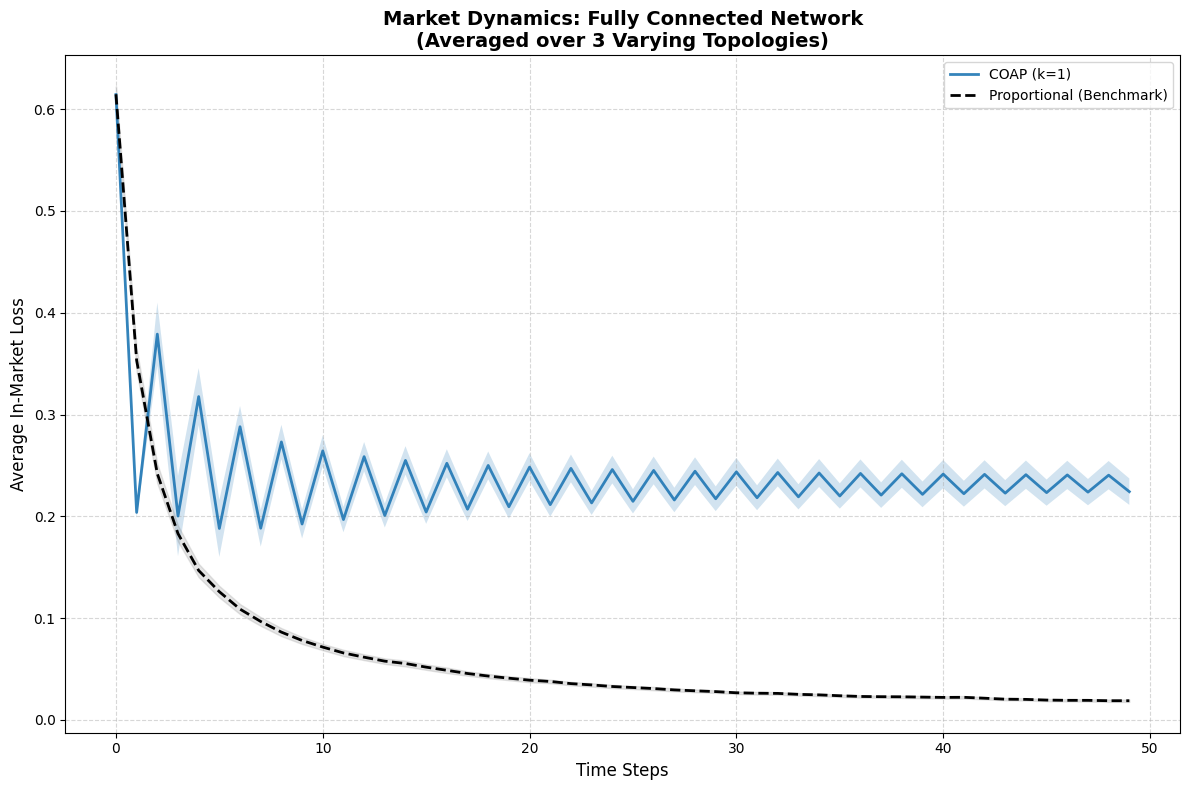


--- Summary Stats for Fully Connected ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.2242          0.0130          100.00%
COAP            2     0.2242          0.0130          100.00%
COAP            3     0.2242          0.0130          100.00%
Proportional    -     0.0189          0.0012          100.00%


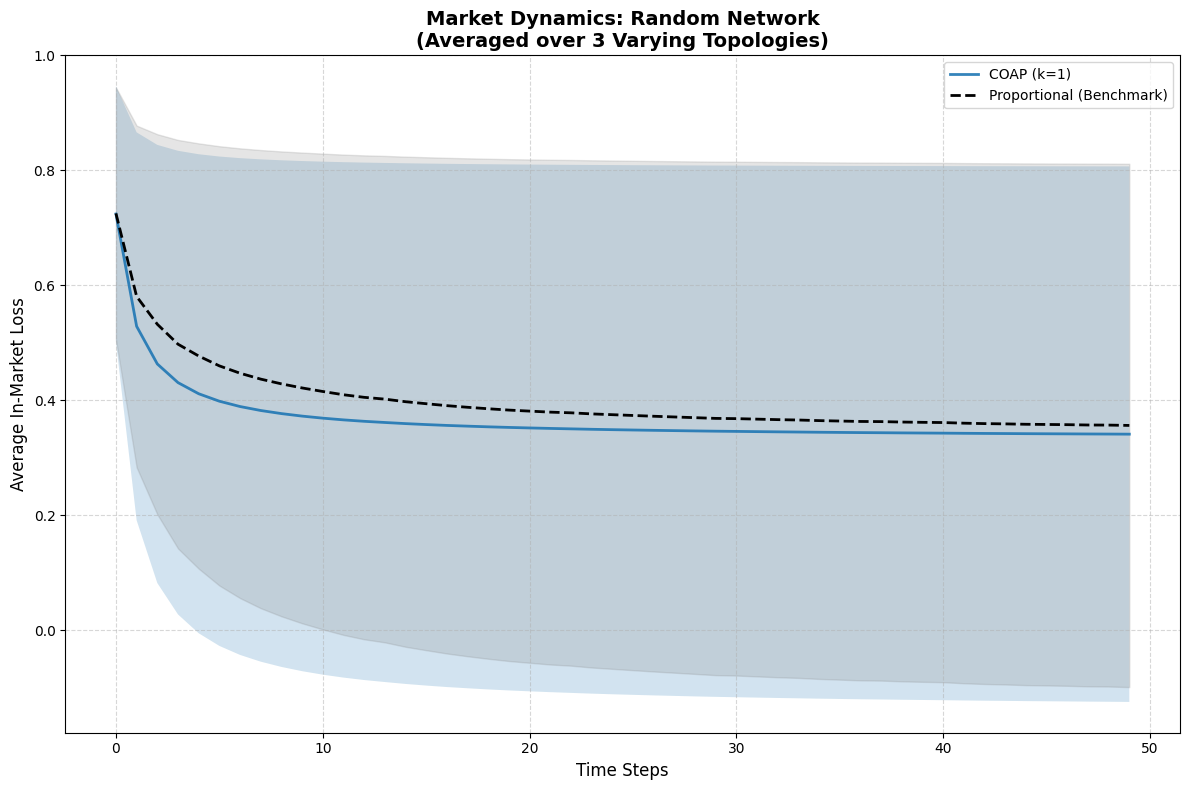


--- Summary Stats for Random ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.3413          0.4658          100.00%
COAP            2     0.3413          0.4658          100.00%
COAP            3     0.3413          0.4658          100.00%
Proportional    -     0.3564          0.4552          100.00%


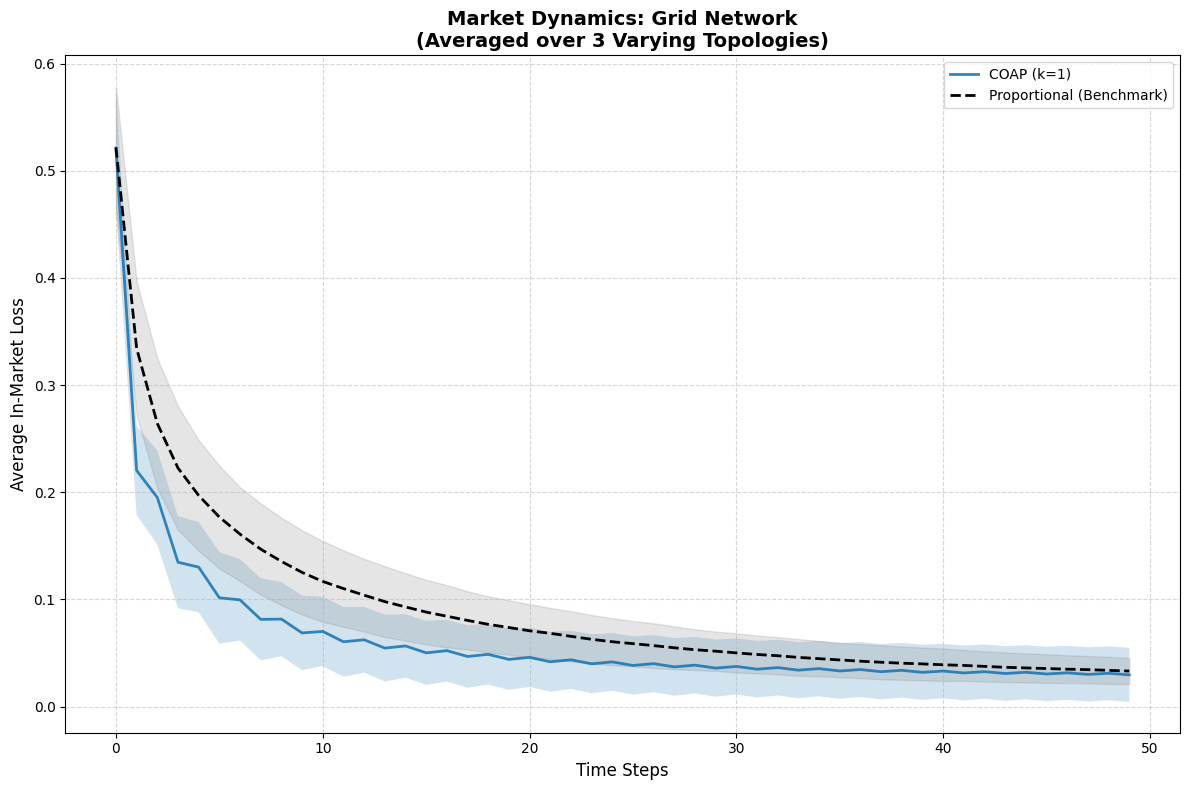


--- Summary Stats for Grid ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.0296          0.0253          100.00%
COAP            2     0.0296          0.0253          100.00%
COAP            3     0.0296          0.0253          100.00%
Proportional    -     0.0331          0.0122          100.00%


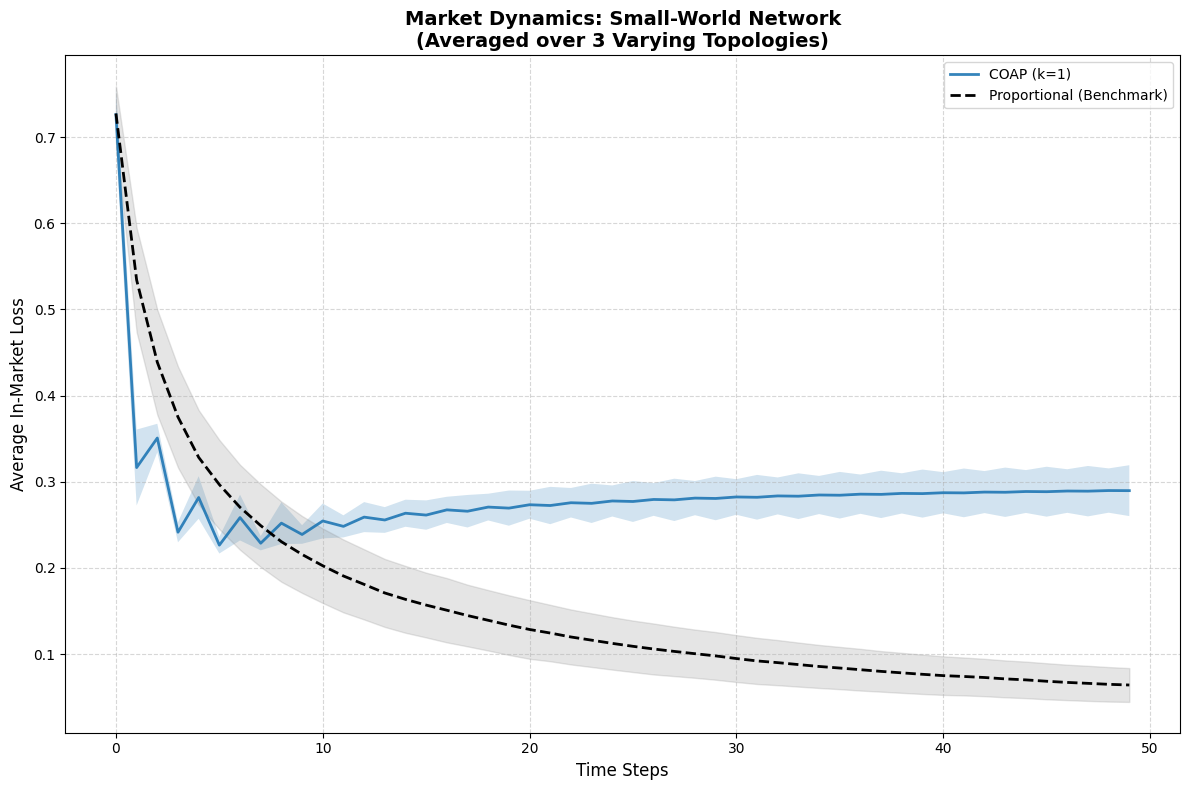


--- Summary Stats for Small-World ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.2897          0.0295          100.00%
COAP            2     0.2897          0.0295          100.00%
COAP            3     0.2897          0.0295          100.00%
Proportional    -     0.0641          0.0196          100.00%

Simulation complete.


In [ ]:
time_steps = np.arange(WINDOW_START, WINDOW_END)

print("\nGenerating Plots with Mean and Std Dev...")

for graph_type in results_store.keys():
    plt.figure(figsize=(12, 8))
    axis = plt.gca()
    
    # Plot COAP agents
    for k in KS:
        data_list = results_store[graph_type]["COAP"][k]
        
        if data_list:
            stacked_data = np.stack(data_list)
            mean_loss = np.mean(stacked_data, axis=0)
            std_loss = np.std(stacked_data, axis=0)
            
            
            label = f"COAP (k={k})"
            
            plt.plot(time_steps, mean_loss, label=label, alpha=0.9, linewidth=2)
            plt.fill_between(time_steps, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2)

    # Plot Benchmarks
    for bench in BENCHMARKS:
        data_list = results_store[graph_type][bench][None]
        if data_list:
            stacked_data = np.stack(data_list)
            mean_loss = np.mean(stacked_data, axis=0)
            std_loss = np.std(stacked_data, axis=0)
            
            label = f"{bench} (Benchmark)"
            
            plt.plot(time_steps, mean_loss, label=label, linestyle='--', color='black', linewidth=2)
            plt.fill_between(time_steps, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2, color='gray')

    plt.xlabel("Time Steps", fontsize=12)
    plt.ylabel("Average In-Market Loss", fontsize=12)
    plt.title(f"Market Dynamics: {graph_type} Network\n(Averaged over {NUM_SEEDS} Varying Topologies)", fontsize=14, fontweight='bold')
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

       # Optional: Print Summary Table for this graph type
    print(f"\n--- Summary Stats for {graph_type} ---")
    print(f"{'Strategy':<15} {'K':<5} {'Final Mean Loss':<15} {'Final Std Dev':<15} {'Avg Health'}")
    print("-" * 60)
    
    # COAP Agents
    for k in KS:
        data = results_store[graph_type]["COAP"][k]
        if data:
            # Ensure we take the last element of each seed run
            final_values = [d[-1] if len(d) > 0 else 0.0 for d in data]
            final_mean = float(np.mean(final_values))
            final_std = float(np.std(final_values))
            avg_health = float(np.mean(crash_rates_store[graph_type]["COAP"][k]))
            print(f"{'COAP':<15} {str(k):<5} {final_mean:<15.4f} {final_std:<15.4f} {avg_health:.2%}")
            
    # Benchmark Agents
    for bench in BENCHMARKS:
        data = results_store[graph_type][bench][None]
        if data:
            # Safety check to ensure data is numeric
            final_values = [float(d[-1]) if len(d) > 0 else 0.0 for d in data]
            final_mean = float(np.mean(final_values))
            # Benchmarks are usually deterministic, so std might be 0 or very small
            final_std = float(np.std(final_values)) 
            
            # Calculate health (usually 100% for proportional unless crashes happen)
            rates = crash_rates_store[graph_type][bench][None]
            avg_health = float(np.mean(rates)) if rates else 1.0
            
            # FIXED: Use explicit variable types to avoid format errors
            print(f"{bench:<15} {'-':<5} {final_mean:<15.4f} {final_std:<15.4f} {avg_health:.2%}")
        else:
            print(f"{bench:<15} {'-':<5} {'N/A':<15} {'N/A':<15} {'N/A':<10}")

print("\nSimulation complete.")